<a href="https://colab.research.google.com/github/shreyasacharya1/ML/blob/main/1BM23CS320_Lab_5_KNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

iris_data = pd.read_csv('/content/iris.csv')
print(iris_data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
X = iris_data.drop('species', axis=1)
y = iris_data['species']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

accuracies = []

for k in range(1, 31): # Iterate k from 1 to 30
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

best_k = np.argmax(accuracies) + 1 # +1 because range starts from 1
accuracy_at_best_k = accuracies[best_k - 1]

print(f"Optimal k for Iris dataset: {best_k}")
print(f"Accuracy at optimal k: {accuracy_at_best_k:.4f}")

Optimal k for Iris dataset: 1
Accuracy at optimal k: 1.0000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

accuracies_diabetes = []

for k in range(1, 31): # Iterate k from 1 to 30
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_diabetes_train_scaled, y_diabetes_train)
    y_pred_diabetes = knn.predict(X_diabetes_test_scaled)
    accuracy_diabetes = accuracy_score(y_diabetes_test, y_pred_diabetes)
    accuracies_diabetes.append(accuracy_diabetes)

best_k_diabetes = np.argmax(accuracies_diabetes) + 1 # +1 because range starts from 1
accuracy_at_best_k_diabetes = accuracies_diabetes[best_k_diabetes - 1]

print(f"Optimal k for Diabetes dataset: {best_k_diabetes}")
print(f"Accuracy at optimal k: {accuracy_at_best_k_diabetes:.4f}")

Optimal k for Diabetes dataset: 21
Accuracy at optimal k: 0.7662


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Train KNN with optimal k for Diabetes dataset
knn_diabetes_optimal = KNeighborsClassifier(n_neighbors=best_k_diabetes)
knn_diabetes_optimal.fit(X_diabetes_train_scaled, y_diabetes_train)
y_pred_diabetes_optimal = knn_diabetes_optimal.predict(X_diabetes_test_scaled)

# Display accuracy
accuracy_diabetes_optimal = accuracy_score(y_diabetes_test, y_pred_diabetes_optimal)
print(f"Accuracy with optimal k for Diabetes dataset: {accuracy_diabetes_optimal:.4f}\n")

# Display confusion matrix
conf_matrix_diabetes = confusion_matrix(y_diabetes_test, y_pred_diabetes_optimal)
print("Confusion Matrix for Diabetes dataset (Optimal k):\n", conf_matrix_diabetes)

# Display classification report
class_report_diabetes = classification_report(y_diabetes_test, y_pred_diabetes_optimal)
print("\nClassification Report for Diabetes dataset (Optimal k):\n", class_report_diabetes)

Accuracy with optimal k for Diabetes dataset: 0.7662

Confusion Matrix for Diabetes dataset (Optimal k):
 [[89 10]
 [26 29]]

Classification Report for Diabetes dataset (Optimal k):
               precision    recall  f1-score   support

           0       0.77      0.90      0.83        99
           1       0.74      0.53      0.62        55

    accuracy                           0.77       154
   macro avg       0.76      0.71      0.72       154
weighted avg       0.76      0.77      0.76       154



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Train KNN with optimal k for Iris dataset
knn_iris_optimal = KNeighborsClassifier(n_neighbors=best_k)
knn_iris_optimal.fit(X_train, y_train)
y_pred_iris_optimal = knn_iris_optimal.predict(X_test)

# Display accuracy
accuracy_iris_optimal = accuracy_score(y_test, y_pred_iris_optimal)
print(f"Accuracy with optimal k for Iris dataset: {accuracy_iris_optimal:.4f}\n")

# Display confusion matrix
conf_matrix_iris = confusion_matrix(y_test, y_pred_iris_optimal)
print("Confusion Matrix for Iris dataset (Optimal k):\n", conf_matrix_iris)

# Display classification report
class_report_iris = classification_report(y_test, y_pred_iris_optimal)
print("\nClassification Report for Iris dataset (Optimal k):\n", class_report_iris)

Accuracy with optimal k for Iris dataset: 1.0000

Confusion Matrix for Iris dataset (Optimal k):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report for Iris dataset (Optimal k):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
yryrrrthrhrrt

In [ ]:
X_iris = iris_data.drop('species', axis=1)
y_iris = iris_data['species']

print(f"Shape of X_iris: {X_iris.shape}")
print(f"Shape of y_iris: {y_iris.shape}")

Shape of X_iris: (150, 4)
Shape of y_iris: (150,)


In [ ]:
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Get the total number of samples
total_samples_iris = len(X_iris)

# Determine the number of samples for the training set (80%)
train_size_iris = int(0.8 * total_samples_iris)

# Create an array of indices and shuffle them
indices_iris = np.arange(total_samples_iris)
np.random.shuffle(indices_iris)

# Split indices into training and testing
train_indices_iris = indices_iris[:train_size_iris]
test_indices_iris = indices_iris[train_size_iris:]

# Use the indices to split the data
X_iris_train = X_iris.iloc[train_indices_iris]
X_iris_test = X_iris.iloc[test_indices_iris]
y_iris_train = y_iris.iloc[train_indices_iris]
y_iris_test = y_iris.iloc[test_indices_iris]

print(f"Shape of X_iris_train: {X_iris_train.shape}")
print(f"Shape of X_iris_test: {X_iris_test.shape}")
print(f"Shape of y_iris_train: {y_iris_train.shape}")
print(f"Shape of y_iris_test: {y_iris_test.shape}")

Shape of X_iris_train: (120, 4)
Shape of X_iris_test: (30, 4)
Shape of y_iris_train: (120,)
Shape of y_iris_test: (30,)


In [ ]:
def euclidean_distance(point1, point2):
    distance = np.sqrt(np.sum((point1 - point2)**2))
    return distance

print("Euclidean distance function defined.")

Euclidean distance function defined.


In [ ]:
from collections import Counter

def knn_predict(X_train, y_train, X_test_point, k):
    distances = [euclidean_distance(X_test_point, x_train_point) for x_train_point in X_train.values]

    # Get k nearest neighbors
    k_nearest_indices = np.argsort(distances)[:k]
    k_nearest_labels = [y_train.iloc[i] for i in k_nearest_indices]

    # Majority vote
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

print("KNN prediction function defined.")

KNN prediction function defined.


In [ ]:
def calculate_accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return correct / len(y_true)

def calculate_confusion_matrix(y_true, y_pred, labels):
    num_labels = len(labels)
    label_to_idx = {label: i for i, label in enumerate(labels)}
    conf_matrix = np.zeros((num_labels, num_labels), dtype=int)

    for true, pred in zip(y_true, y_pred):
        true_idx = label_to_idx.get(true)
        pred_idx = label_to_idx.get(pred)
        if true_idx is not None and pred_idx is not None:
            conf_matrix[true_idx, pred_idx] += 1
    return conf_matrix

def generate_classification_report(y_true, y_pred, labels):
    conf_matrix = calculate_confusion_matrix(y_true, y_pred, labels)
    report_lines = []
    report_lines.append(f"{'':<15}{'precision':>10}{'recall':>10}{'f1-score':>10}{'support':>10}")
    report_lines.append("\n")

    precision_scores = []
    recall_scores = []
    f1_scores = []
    supports = []

    for i, label in enumerate(labels):
        tp = conf_matrix[i, i]
        fp = np.sum(conf_matrix[:, i]) - tp
        fn = np.sum(conf_matrix[i, :]) - tp
        support = np.sum(conf_matrix[i, :])

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1_score)
        supports.append(support)

        report_lines.append(f"{str(label):<15}{precision:>10.2f}{recall:>10.2f}{f1_score:>10.2f}{support:>10}")

    # Macro average
    macro_precision = np.mean(precision_scores)
    macro_recall = np.mean(recall_scores)
    macro_f1 = np.mean(f1_scores)
    total_support = np.sum(supports)

    report_lines.append("\n")
    report_lines.append(f"{'accuracy':<15}{'':>10}{'':>10}{'':>10}{total_support:>10}")
    report_lines.append(f"{'macro avg':<15}{macro_precision:>10.2f}{macro_recall:>10.2f}{macro_f1:>10.2f}{total_support:>10}")

    # Weighted average (for accuracy)
    weighted_avg_precision = np.sum([p * s for p, s in zip(precision_scores, supports)]) / total_support if total_support > 0 else 0
    weighted_avg_recall = np.sum([r * s for r, s in zip(recall_scores, supports)]) / total_support if total_support > 0 else 0
    weighted_avg_f1 = np.sum([f * s for f, s in zip(f1_scores, supports)]) / total_support if total_support > 0 else 0

    report_lines.append(f"{'weighted avg':<15}{weighted_avg_precision:>10.2f}{weighted_avg_recall:>10.2f}{weighted_avg_f1:>10.2f}{total_support:>10}")

    return "\n".join(report_lines)

print("Manual evaluation metrics (accuracy, confusion matrix, classification report) functions defined.")

Manual evaluation metrics (accuracy, confusion matrix, classification report) functions defined.


In [ ]:
accuracies_iris_manual = []
k_range = range(1, 31)

for k in k_range:
    y_pred_iris_manual = [knn_predict(X_iris_train, y_iris_train, x_test_point, k) for x_test_point in X_iris_test.values]
    accuracy = calculate_accuracy(y_iris_test, y_pred_iris_manual)
    accuracies_iris_manual.append(accuracy)

best_k_iris_manual = k_range[np.argmax(accuracies_iris_manual)]
accuracy_at_best_k_iris_manual = np.max(accuracies_iris_manual)

print(f"Optimal k for Iris dataset (manual KNN): {best_k_iris_manual}")
print(f"Accuracy at optimal k (manual KNN): {accuracy_at_best_k_iris_manual:.4f}")

Optimal k for Iris dataset (manual KNN): 1
Accuracy at optimal k (manual KNN): 0.9667


In [ ]:
y_pred_iris_optimal_manual = [knn_predict(X_iris_train, y_iris_train, x_test_point, best_k_iris_manual) for x_test_point in X_iris_test.values]

# Display accuracy
accuracy_iris_optimal_manual = calculate_accuracy(y_iris_test, y_pred_iris_optimal_manual)
print(f"Accuracy with optimal k for Iris dataset (manual KNN): {accuracy_iris_optimal_manual:.4f}\n")

# Display confusion matrix
iris_labels = y_iris.unique()
conf_matrix_iris_manual = calculate_confusion_matrix(y_iris_test, y_pred_iris_optimal_manual, iris_labels)
print("Confusion Matrix for Iris dataset (manual KNN):\n", conf_matrix_iris_manual)

# Display classification report
class_report_iris_manual = generate_classification_report(y_iris_test, y_pred_iris_optimal_manual, iris_labels)
print("\nClassification Report for Iris dataset (manual KNN):\n", class_report_iris_manual)

Accuracy with optimal k for Iris dataset (manual KNN): 0.9667

Confusion Matrix for Iris dataset (manual KNN):
 [[ 7  0  0]
 [ 0 11  0]
 [ 0  1 11]]

Classification Report for Iris dataset (manual KNN):
                 precision    recall  f1-score   support


setosa               1.00      1.00      1.00         7
versicolor           0.92      1.00      0.96        11
virginica            1.00      0.92      0.96        12


accuracy                                             30
macro avg            0.97      0.97      0.97        30
weighted avg         0.97      0.97      0.97        30


In [ ]:
diabetes_data = pd.read_csv('/content/diabetes.csv')

X_diabetes = diabetes_data.drop('Outcome', axis=1)
y_diabetes = diabetes_data['Outcome']

print(f"Shape of X_diabetes: {X_diabetes.shape}")
print(f"Shape of y_diabetes: {y_diabetes.shape}")

Shape of X_diabetes: (768, 8)
Shape of y_diabetes: (768,)


In [ ]:
np.random.seed(42)

total_samples_diabetes = len(X_diabetes)
train_size_diabetes = int(0.8 * total_samples_diabetes)

indices_diabetes = np.arange(total_samples_diabetes)
np.random.shuffle(indices_diabetes)

train_indices_diabetes = indices_diabetes[:train_size_diabetes]
test_indices_diabetes = indices_diabetes[train_size_diabetes:]

X_diabetes_train = X_diabetes.iloc[train_indices_diabetes]
X_diabetes_test = X_diabetes.iloc[test_indices_diabetes]
y_diabetes_train = y_diabetes.iloc[train_indices_diabetes]
y_diabetes_test = y_diabetes.iloc[test_indices_diabetes]

print(f"Shape of X_diabetes_train: {X_diabetes_train.shape}")
print(f"Shape of X_diabetes_test: {X_diabetes_test.shape}")
print(f"Shape of y_diabetes_train: {y_diabetes_train.shape}")
print(f"Shape of y_diabetes_test: {y_diabetes_test.shape}")

Shape of X_diabetes_train: (614, 8)
Shape of X_diabetes_test: (154, 8)
Shape of y_diabetes_train: (614,)
Shape of y_diabetes_test: (154,)


In [ ]:
def manual_standard_scaler_fit(X):
    means = X.mean()
    stds = X.std()
    return means, stds

print("Manual StandardScaler fit function defined.")

Manual StandardScaler fit function defined.


In [ ]:
def manual_standard_scaler_transform(X, means, stds):
    # Ensure we don't divide by zero for constant features
    stds_safe = stds.replace(0, 1) # Replace 0 std with 1 to avoid division by zero
    scaled_X = (X - means) / stds_safe
    return scaled_X

print("Manual StandardScaler transform function defined.")

Manual StandardScaler transform function defined.


In [ ]:
means_diabetes, stds_diabetes = manual_standard_scaler_fit(X_diabetes_train)

X_diabetes_train_scaled = manual_standard_scaler_transform(X_diabetes_train, means_diabetes, stds_diabetes)
X_diabetes_test_scaled = manual_standard_scaler_transform(X_diabetes_test, means_diabetes, stds_diabetes)

print("X_diabetes_train_scaled shape:", X_diabetes_train_scaled.shape)
print("X_diabetes_test_scaled shape:", X_diabetes_test_scaled.shape)
print("First 5 rows of X_diabetes_train_scaled:")
print(X_diabetes_train_scaled.head())

X_diabetes_train_scaled shape: (614, 8)
X_diabetes_test_scaled shape: (154, 8)
First 5 rows of X_diabetes_train_scaled:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
668     0.648948 -0.702943      -0.547017       0.780918  0.929898  0.254444   
324    -0.536046 -0.264890       0.305823       0.718664 -0.694764  0.463372   
624    -0.536046 -0.390048      -0.246015      -1.273479 -0.694764 -0.138831   
690     1.241445 -0.421338       0.556659      -1.273479 -0.694764 -0.900802   
473     0.945197  0.486057       1.058330      -1.273479 -0.694764 -0.249440   

     DiabetesPedigreeFunction       Age  
668                 -0.115722  0.821380  
324                 -0.972337 -1.034936  
624                 -0.941960 -1.034936  
690                  1.178313  0.061978  
473                 -0.784003  1.412026  


In [ ]:
accuracies_diabetes_manual = []
k_range_diabetes = range(1, 31)

for k in k_range_diabetes:
    y_pred_diabetes_manual = [knn_predict(X_diabetes_train_scaled, y_diabetes_train, x_test_point, k) for x_test_point in X_diabetes_test_scaled.values]
    accuracy = calculate_accuracy(y_diabetes_test, y_pred_diabetes_manual)
    accuracies_diabetes_manual.append(accuracy)

best_k_diabetes_manual = k_range_diabetes[np.argmax(accuracies_diabetes_manual)]
accuracy_at_best_k_diabetes_manual = np.max(accuracies_diabetes_manual)

print(f"Optimal k for Diabetes dataset (manual KNN): {best_k_diabetes_manual}")
print(f"Accuracy at optimal k (manual KNN): {accuracy_at_best_k_diabetes_manual:.4f}")

Optimal k for Diabetes dataset (manual KNN): 15
Accuracy at optimal k (manual KNN): 0.7597


In [ ]:
y_pred_diabetes_optimal_manual = [knn_predict(X_diabetes_train_scaled, y_diabetes_train, x_test_point, best_k_diabetes_manual) for x_test_point in X_diabetes_test_scaled.values]

# Display accuracy
accuracy_diabetes_optimal_manual = calculate_accuracy(y_diabetes_test, y_pred_diabetes_optimal_manual)
print(f"Accuracy with optimal k for Diabetes dataset (manual KNN): {accuracy_diabetes_optimal_manual:.4f}\n")

# Display confusion matrix
diabetes_labels = y_diabetes.unique().tolist() # Ensure labels are in a list for consistent order
conf_matrix_diabetes_manual = calculate_confusion_matrix(y_diabetes_test, y_pred_diabetes_optimal_manual, diabetes_labels)
print("Confusion Matrix for Diabetes dataset (manual KNN):\n", conf_matrix_diabetes_manual)

# Display classification report
class_report_diabetes_manual = generate_classification_report(y_diabetes_test, y_pred_diabetes_optimal_manual, diabetes_labels)
print("\nClassification Report for Diabetes dataset (manual KNN):\n", class_report_diabetes_manual)

Accuracy with optimal k for Diabetes dataset (manual KNN): 0.7597

Confusion Matrix for Diabetes dataset (manual KNN):
 [[32 26]
 [11 85]]

Classification Report for Diabetes dataset (manual KNN):
                 precision    recall  f1-score   support


1                    0.74      0.55      0.63        58
0                    0.77      0.89      0.82        96


accuracy                                            154
macro avg            0.75      0.72      0.73       154
weighted avg         0.76      0.76      0.75       154


In [ ]:
import pandas as pd
import numpy as np

# Load data
data = pd.read_csv('/content/diabetes.csv')
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Train-test split
np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Manual scaling
mean = X_train.mean()
std = X_train.std().replace(0,1)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Distance function
def dist(a,b):
    return np.sqrt(np.sum((a-b)**2))

# KNN predict
def knn_predict(X_train, y_train, x, k):
    d = [dist(x, X_train.iloc[i].values) for i in range(len(X_train))]
    idx = np.argsort(d)[:k]
    return y_train.iloc[idx].mode()[0]

# Accuracy
def accuracy(y_true, y_pred):
    return np.mean(y_true.values == y_pred)

# Find best k
best_k, best_acc = 1, 0
for k in range(1,31):
    preds = [knn_predict(X_train, y_train, x, k) for x in X_test.values]
    acc = accuracy(y_test, preds)
    if acc > best_acc:
        best_k, best_acc = k, acc

print("Best k:", best_k)
print("Accuracy:", best_acc)

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("heart.csv")
X = data.drop("target", axis=1)
y = data["target"]

# Train-test split
np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Manual scaling
mean, std = X_train.mean(), X_train.std().replace(0,1)
X_train = (X_train-mean)/std
X_test = (X_test-mean)/std

# Distance
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

# KNN predict
def knn(x, k):
    d = [distance(x, X_train.iloc[i].values) for i in range(len(X_train))]
    idx = np.argsort(d)[:k]
    labels = y_train.iloc[idx]
    return Counter(labels).most_common(1)[0][0]

# Find best k
best_k, best_acc = 1, 0
for k in range(1,21):
    preds = [knn(x,k) for x in X_test.values]
    acc = np.mean(preds == y_test.values)
    if acc > best_acc:
        best_k, best_acc = k, acc

print("Best k:", best_k)
print("Accuracy:", best_acc)

# Final prediction
y_pred = [knn(x,best_k) for x in X_test.values]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

IRIS Accuracy: 1.0
IRIS Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



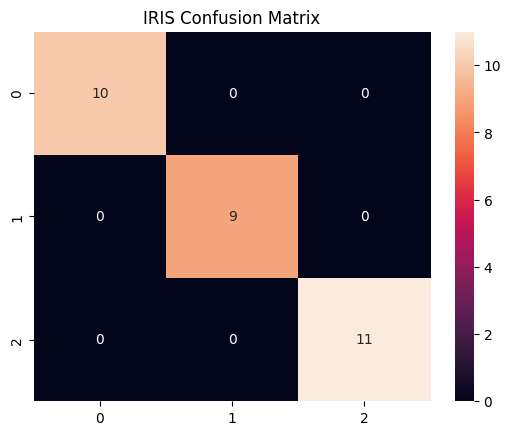


Diabetes Accuracy: 0.6818181818181818
Diabetes Confusion Matrix:
 [[78 21]
 [28 27]]

Heart Best k: 11
Heart Accuracy: 0.7540983606557377
Heart Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



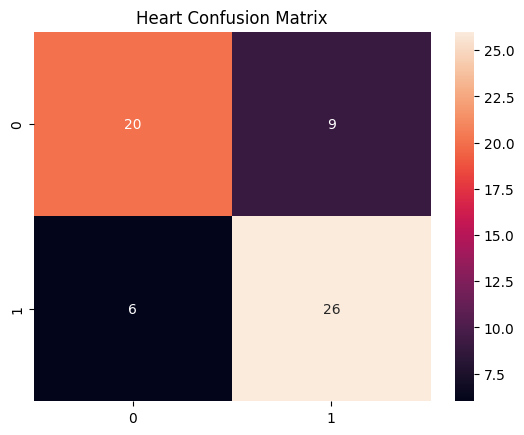

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------- 1. IRIS DATASET ----------
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("IRIS Accuracy:", accuracy_score(y_test, y_pred))
print("IRIS Classification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("IRIS Confusion Matrix")
plt.show()


# ---------- 2. DIABETES DATASET ----------
diabetes = pd.read_csv("diabetes.csv")
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("\nDiabetes Accuracy:", accuracy_score(y_test, y_pred))
print("Diabetes Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# ---------- 3. HEART DATASET ----------
heart = pd.read_csv("heart.csv")
X = heart.drop("target", axis=1)
y = heart["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

best_k, best_acc = 1, 0
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    if acc > best_acc:
        best_k, best_acc = k, acc

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nHeart Best k:", best_k)
print("Heart Accuracy:", accuracy_score(y_test, y_pred))
print("Heart Classification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Heart Confusion Matrix")
plt.show()